In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/master/diamonds.csv")

In [5]:
df.carat

0        0.23
1        0.21
2        0.23
3        0.29
4        0.31
         ... 
53935    0.72
53936    0.72
53937    0.70
53938    0.86
53939    0.75
Name: carat, Length: 53940, dtype: float64

In [6]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


<AxesSubplot:ylabel='Frequency'>

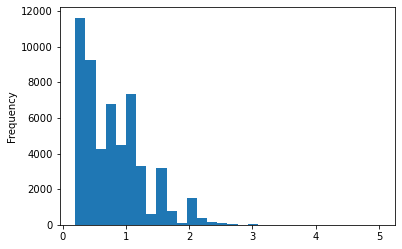

In [10]:
df.carat.plot.hist(bins = 30)

(array([2.5155e+04, 1.8626e+04, 7.1290e+03, 2.3490e+03, 6.1400e+02,
        5.3000e+01, 6.0000e+00, 5.0000e+00, 2.0000e+00, 1.0000e+00]),
 array([0.2  , 0.681, 1.162, 1.643, 2.124, 2.605, 3.086, 3.567, 4.048,
        4.529, 5.01 ]),
 <BarContainer object of 10 artists>)

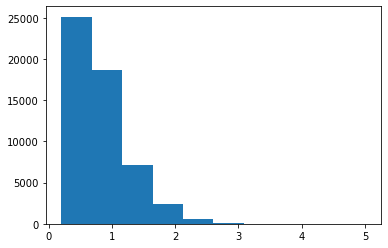

In [8]:
plt.hist(df.carat)

<AxesSubplot:ylabel='Frequency'>

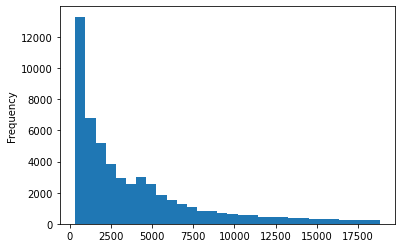

In [11]:
df.price.plot.hist(bins = 30)

<AxesSubplot:>

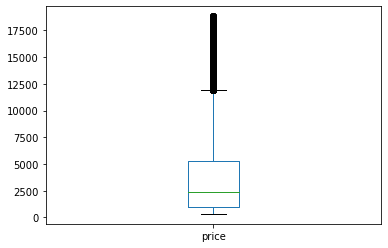

In [15]:
df.price.plot.box()

In [16]:
import numpy as np

In [29]:

def find_outliers(a):
    median = np.median(a)
    q1, q2, q3 = np.percentile(a, [25, 50, 75])
    iqr = q3 - q1
    upper_whisker = min(np.max(a), q3 + 1.5*iqr)
    lower_whisker = max(np.min(a), q1 - 1.5*iqr)
    print("lower whisker", lower_whisker, "upper_whisker", upper_whisker)
    return (a<lower_whisker) | (a>upper_whisker)
find_outliers(a)

lower whisker 326 upper_whisker 11885.625


0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: price, Length: 53940, dtype: bool

In [21]:
median, q1, q2, q3, iqr

(2401.0, 950.0, 2401.0, 5324.25, 4374.25)

In [27]:
find_outliers(a).mean()

0.06562847608453838

In [30]:
df[find_outliers(a)]

lower whisker 326 upper_whisker 11885.625


,carat,cut,color,clarity,depth,table,price,x,y,z
23820,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68
...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04


<AxesSubplot:ylabel='Frequency'>

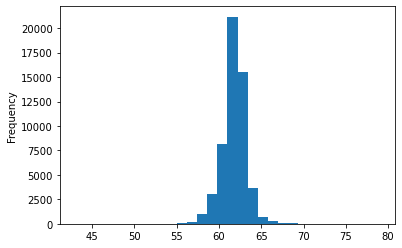

In [33]:
df.depth.plot.hist(bins = 30)

<AxesSubplot:>

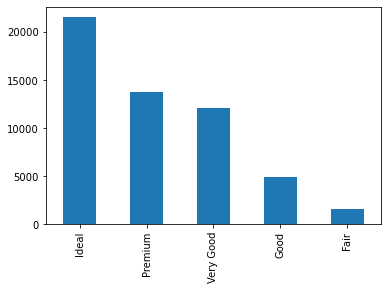

In [36]:
df.cut.value_counts().plot.bar()

<BarContainer object of 5 artists>

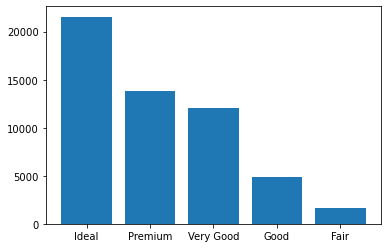

In [38]:
a = df.cut.value_counts()
plt.bar(a.index, a)

<AxesSubplot:ylabel='cut'>

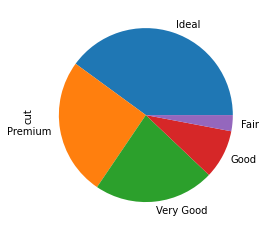

In [39]:
df.cut.value_counts().plot.pie()

continuous: hist, boxplot
categorical: frequency, pie

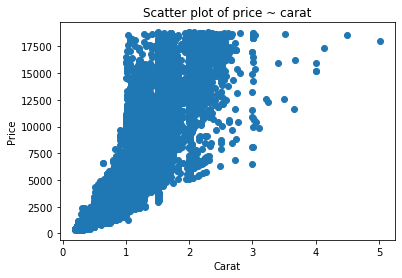

In [46]:
plt.scatter(df.carat, df.price)
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Scatter plot of price ~ carat")

plt.savefig("/Users/abasar/Downloads/plt.pdf")

<AxesSubplot:xlabel='carat', ylabel='price'>

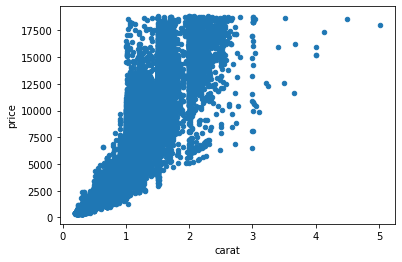

In [47]:
df.plot.scatter("carat", "price")

<AxesSubplot:xlabel='cut'>

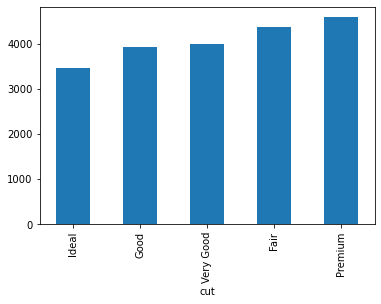

In [50]:
df.groupby("cut").price.mean().sort_values().plot.bar()

<AxesSubplot:xlabel='cut'>

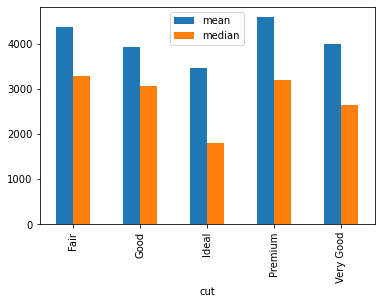

In [53]:
df.groupby("cut").price.agg(["mean", "median"]).plot.bar()

In [58]:
a = df.groupby(["cut", "color"]).price.mean().unstack()

In [59]:
import seaborn as sns

<AxesSubplot:xlabel='color', ylabel='cut'>

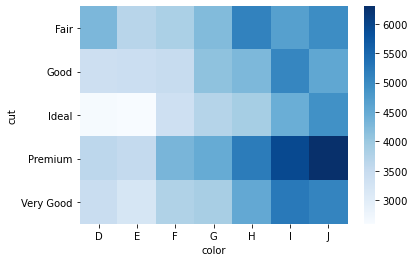

In [63]:
sns.heatmap(a, cmap="Blues")